# FarmTech Solutions — Machine Learning na Cabeça
**FIAP · Fase 5 · Entrega 1**  
**Integrante:** Gabriel Marcolino Ramos · **RM:** PENDENTE

## 1. Problema e escopo
Prever o rendimento de quatro culturas a partir da cultura e de quatro variáveis
climáticas, além de explorar perfis de produtividade e observações discrepantes.
O cenário é uma fazenda de 200 hectares; o CSV não comprova que seus registros
foram efetivamente coletados nessa propriedade.

O relatório contém auditoria, análise exploratória, cinco algoritmos de regressão,
validação agrupada, comparação com referências simples, clusterização e outliers.
A comparação AWS está no [README](../README.md).

**Reprodução:** Python 3.12, dependências fixadas em `requirements.txt` e semente 42.
Na raiz do repositório, execute `python scripts/executar_notebook.py`.
O sufixo `pbl_fase4.ipynb` segue literalmente o enunciado, embora o projeto seja da Fase 5.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED = 42
# Localiza a raiz tanto na execução pelo script quanto com Jupyter em notebooks/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/crop_yield.csv').exists())
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
VERSIONS = {p: metadata.version(p) for p in ['pandas', 'numpy', 'scikit-learn', 'matplotlib']}
print('Python:', platform.python_version(), '| Bibliotecas:', VERSIONS)

Python: 3.12.3 | Bibliotecas: {'pandas': '3.0.5', 'numpy': '2.5.3', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1'}


## 2. Proveniência, dicionário e auditoria
Usamos a cópia local de `crop_yield.csv` encontrada na pasta Downloads, com os seis
campos previstos no enunciado. O hash permite identificar exatamente a versão analisada;
a vinculação dessa cópia ao anexo do portal deve ser confirmada pelo integrante.
Não há data, fazenda, país, tipo de solo, manejo ou identificação de safra no arquivo.

| Campo original | Significado informado | Uso |
|---|---|---|
| Crop | Cultura | Entrada categórica |
| Precipitation (mm day-1) | Precipitação em mm/dia | Entrada numérica |
| Specific Humidity at 2 Meters (g/kg) | Umidade específica em g/kg | Entrada numérica |
| Relative Humidity at 2 Meters (%) | Umidade relativa em % | Entrada numérica |
| Temperature at 2 Meters (C) | Temperatura em °C | Entrada numérica |
| Yield | Rendimento, declarado como t/ha | Alvo |

**Unidades a confirmar:** os valores de `Yield` e da precipitação têm ordens de grandeza
que exigem conferência da documentação da base. Não convertemos os dados por suposição.
MAE, RMSE, previsões e eixos de rendimento serão apresentados em **unidades originais do CSV**.
Não é defensável estimar toneladas totais nos 200 hectares enquanto isso não for esclarecido.

In [2]:
path = ROOT / 'data/crop_yield.csv'
sha256 = hashlib.sha256(path.read_bytes()).hexdigest()
raw = pd.read_csv(path)
RENAME = {'Crop':'cultura', 'Precipitation (mm day-1)':'precipitacao',
          'Specific Humidity at 2 Meters (g/kg)':'umidade_especifica',
          'Relative Humidity at 2 Meters (%)':'umidade_relativa',
          'Temperature at 2 Meters (C)':'temperatura', 'Yield':'rendimento'}
assert set(raw.columns) == set(RENAME), 'O esquema do CSV foi alterado; revise o dicionário.'
df = raw.rename(columns=RENAME).copy()
NUM = ['precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura']
FEATURES = ['cultura', *NUM]
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in [*NUM, 'rendimento'])
assert np.isfinite(df[[*NUM, 'rendimento']].dropna().to_numpy()).all()
assert df['rendimento'].notna().all(), 'Não imputamos valores do alvo.'
assert df['cultura'].notna().all()
assert not df.duplicated().any(), 'Revise duplicatas antes da divisão.'
assert df['umidade_relativa'].between(0, 100).all()
assert (df[['precipitacao','umidade_especifica','rendimento']] >= 0).all().all()
print('SHA-256:', sha256)
display(pd.DataFrame({'tipo':df.dtypes.astype(str), 'ausentes':df.isna().sum(), 'distintos':df.nunique()}))
display(df.head())
# As quatro culturas compartilham as mesmas combinações climáticas.
groups = df.groupby(NUM, sort=True, dropna=False).ngroup()
print('Registros:', len(df), '| Duplicatas:', df.duplicated().sum(), '| Grupos climáticos:', groups.nunique())
display(df['cultura'].value_counts().rename('registros').to_frame())

SHA-256: 07b3335f497e08e705b5835ee334426ac16cb24732c1bfaa994254d39f771b1b


,tipo,ausentes,distintos
cultura,str,0,4
precipitacao,float64,0,39
umidade_especifica,float64,0,33
umidade_relativa,float64,0,38
temperatura,float64,0,29
rendimento,int64,0,155


,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


Registros: 156 | Duplicatas: 0 | Grupos climáticos: 39


,registros
cultura,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


## 3. Separação antes da exploração do alvo
Há 156 observações, quatro culturas com 39 registros cada e somente 39 combinações
climáticas. Usamos a combinação das quatro variáveis como grupo: um mesmo cenário
não pode aparecer simultaneamente no treino e no teste. Essa identificação é conservadora;
a coincidência climática não comprova uma data ou local comum.

Reservamos aproximadamente 20% dos grupos para o teste, com semente fixa. No treino,
usamos cinco partições de `GroupKFold`. Imputação, escala, codificação e ajuste de
hiperparâmetros são aprendidos dentro das partições de treino. O conjunto reservado
é consultado somente após selecionar o algoritmo pelo RMSE de validação.

Não há datas para realizar um teste temporal. Portanto, este experimento estima
interpolação em cenários semelhantes, e não capacidade de prever uma safra futura.

In [3]:
X, y = df[FEATURES], df['rendimento']
train_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED).split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]
assert set(g_train).isdisjoint(set(g_test))
cv_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, g_train))
for a, b in cv_splits:
    assert set(g_train.iloc[a]).isdisjoint(set(g_train.iloc[b]))
particao = pd.DataFrame({'linha_csv': df.index + 2, 'grupo': groups, 'particao': 'treino'})
particao.loc[test_idx, 'particao'] = 'teste'
particao.to_csv(OUT / 'particoes.csv', index=False)
print(f'Treino: {len(train_idx)} linhas / {g_train.nunique()} grupos; teste: {len(test_idx)} linhas / {g_test.nunique()} grupos.')

Treino: 124 linhas / 31 grupos; teste: 32 linhas / 8 grupos.


## 4. Análise exploratória do treino
A análise do rendimento usa somente o treino para orientar a modelagem. Comparamos
as culturas separadamente, pois as diferenças de escala podem dominar a correlação
e o R² global. Correlação descreve associação, sem estabelecer causalidade.

,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
count,124.00,124.00,124.00,124.00,124.00
mean,2467.18,18.20,84.65,26.20,56113.49
std,290.35,0.29,0.96,0.26,70686.33
min,1934.62,17.54,82.11,25.56,5571.00
25%,2302.99,18.03,84.12,26.03,8170.00
50%,2414.79,18.27,84.67,26.18,18871.00
75%,2692.34,18.38,85.45,26.35,65773.50
max,3085.79,18.70,86.10,26.81,203399.00


,count,mean,median,std,min,max
cultura,,,,,,
"Cocoa, beans",31,8674.74,8300.0,1695.93,5765,13056
Oil palm fruit,31,176030.42,177543.0,16106.23,142425,203399
"Rice, paddy",31,31924.16,30676.0,4719.55,24686,40223
"Rubber, natural",31,7824.65,7817.0,1517.83,5571,10285


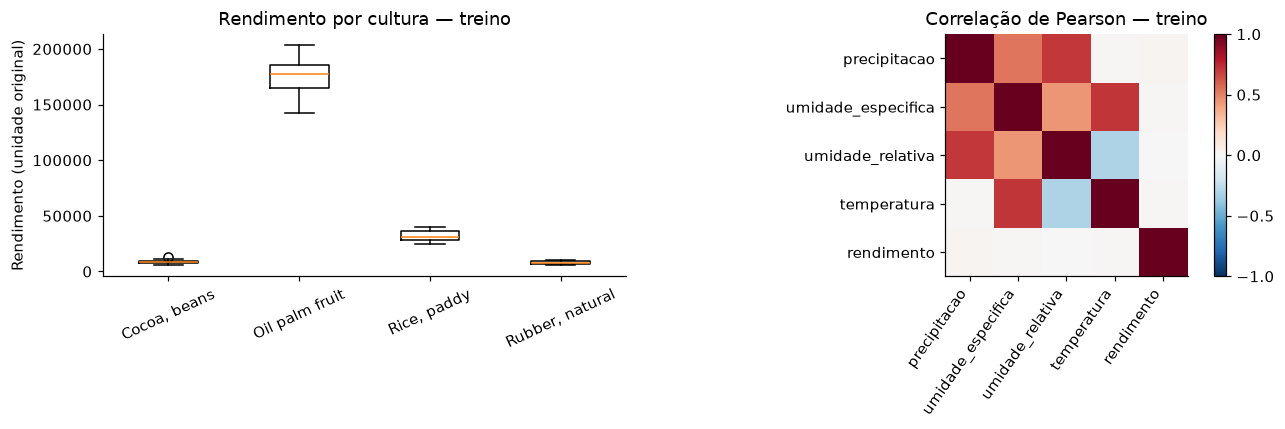

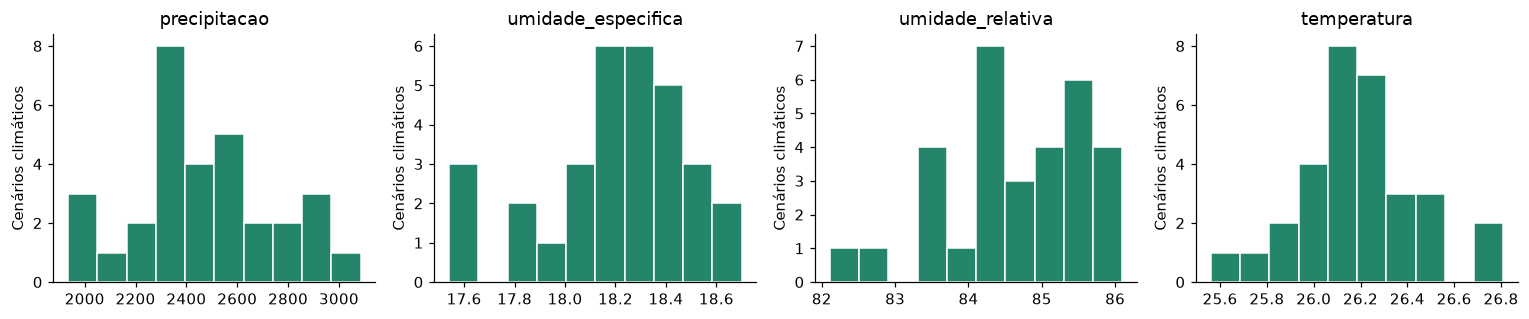

In [4]:
train = df.iloc[train_idx].copy()
display(train.describe().round(2))
resumo_cultura = train.groupby('cultura')['rendimento'].agg(['count','mean','median','std','min','max'])
display(resumo_cultura.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
culturas = sorted(train['cultura'].unique())
axes[0].boxplot([train.loc[train.cultura == c, 'rendimento'] for c in culturas], tick_labels=culturas)
axes[0].tick_params(axis='x', rotation=25)
axes[0].set(ylabel='Rendimento (unidade original)', title='Rendimento por cultura — treino')
corr = train[NUM + ['rendimento']].corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_xticks(range(5), corr.columns, rotation=55, ha='right')
axes[1].set_yticks(range(5), corr.columns)
axes[1].set_title('Correlação de Pearson — treino')
fig.colorbar(im, ax=axes[1])
fig.tight_layout()
fig.savefig(OUT / 'eda.png', bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, c in zip(axes, NUM):
    ax.hist(train.drop_duplicates(NUM)[c], bins=10, color='#24856b', edgecolor='white')
    ax.set(title=c, ylabel='Cenários climáticos')
fig.tight_layout()
plt.show()

In [5]:
maior = resumo_cultura['median'].idxmax()
menor = resumo_cultura['median'].idxmin()
display(Markdown(f'**Achado do treino:** `{maior}` tem a maior mediana ({resumo_cultura.loc[maior,"median"]:,.1f}), '
                 f'e `{menor}` a menor ({resumo_cultura.loc[menor,"median"]:,.1f}), na escala original. '
                 'Essa separação entre culturas exige uma referência que use apenas a cultura, '
                 'para verificar se as variáveis climáticas acrescentam capacidade preditiva.'))
# Correlações internas evitam confundir o efeito da cultura com o do clima.
display(train.groupby('cultura')[[*NUM, 'rendimento']].corr()['rendimento'].unstack().drop(columns='rendimento').round(3))

**Achado do treino:** `Oil palm fruit` tem a maior mediana (177,543.0), e `Rubber, natural` a menor (7,817.0), na escala original. Essa separação entre culturas exige uma referência que use apenas a cultura, para verificar se as variáveis climáticas acrescentam capacidade preditiva.

,precipitacao,umidade_especifica,umidade_relativa,temperatura
cultura,,,,
"Cocoa, beans",0.172,-0.025,-0.107,0.057
Oil palm fruit,0.279,0.023,0.008,0.013
"Rice, paddy",0.420,0.699,0.226,0.563
"Rubber, natural",0.133,-0.383,-0.003,-0.398


## 5. Cinco algoritmos e referências
1. **Regressão linear:** relação aditiva simples, interpretável; não modela não linearidades.
2. **Árvore de decisão:** regras e interações; sensível a amostras pequenas.
3. **Random Forest:** média de árvores; reduz variância, sem extrapolar bem.
4. **KNN:** usa vizinhos; depende da escala e de representatividade local.
5. **SVR com kernel RBF:** relações suaves não lineares; depende de C e da escala.

Usamos grids pequenos, definidos antes do teste, para limitar sobreajuste de seleção
em uma amostra pequena. Todos recebem one-hot de cultura e variáveis numéricas
padronizadas. Padronizamos também o alvo **dentro de cada ajuste**, com
`TransformedTargetRegressor`; as previsões retornam automaticamente à escala original.

As referências adicionais não contam entre os cinco algoritmos: média global
(`DummyRegressor`) e média por cultura (regressão linear apenas sobre one-hot).
Selecionamos pelo menor **RMSE médio de validação**. O MAE mede erro absoluto típico;
o RMSE penaliza erros grandes; R² compara com a média, podendo ser negativo.
O desvio entre folds não é intervalo de confiança. A pontuação do melhor grid sofre
viés de seleção; o teste separado é a avaliação final.

In [6]:
def pipeline(model):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
    pre = ColumnTransformer([
        ('numeric', numeric, NUM),
        ('crop', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['cultura'])
    ])
    return Pipeline([('pre', pre), ('model', TransformedTargetRegressor(regressor=model, transformer=StandardScaler()))])

specs = {
    'Regressão linear': (LinearRegression(), {}),
    'Árvore de decisão': (DecisionTreeRegressor(random_state=SEED),
                          {'model__regressor__max_depth':[3,5,None], 'model__regressor__min_samples_leaf':[2,5]}),
    'Random Forest': (RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1),
                      {'model__regressor__max_depth':[5,None], 'model__regressor__min_samples_leaf':[1,3,5]}),
    'KNN': (KNeighborsRegressor(),
            {'model__regressor__n_neighbors':[3,5,9], 'model__regressor__weights':['uniform','distance']}),
    'SVR (RBF)': (SVR(kernel='rbf'),
                  {'model__regressor__C':[1,10,100], 'model__regressor__epsilon':[0.05,0.1]})
}
scoring = {'mae':'neg_mean_absolute_error', 'rmse':'neg_root_mean_squared_error', 'r2':'r2'}
searches, rows = {}, []
for name, (model, grid) in specs.items():
    search = GridSearchCV(pipeline(model), grid, scoring=scoring, refit='rmse', cv=cv_splits, n_jobs=1, error_score='raise')
    search.fit(X_train, y_train)
    searches[name] = search
    j = search.best_index_
    rows.append({'modelo':name, 'MAE_CV':-search.cv_results_['mean_test_mae'][j],
                 'RMSE_CV':-search.cv_results_['mean_test_rmse'][j],
                 'RMSE_desvio_CV':search.cv_results_['std_test_rmse'][j],
                 'R2_CV':search.cv_results_['mean_test_r2'][j],
                 'parametros':json.dumps(search.best_params_, ensure_ascii=False)})
comparison = pd.DataFrame(rows).sort_values('RMSE_CV').reset_index(drop=True)
winner = comparison.iloc[0]['modelo']
best = searches[winner].best_estimator_
comparison.to_csv(OUT / 'modelos_validacao.csv', index=False)
display(comparison.round(3))
print('Escolha congelada antes do teste:', winner)

,modelo,MAE_CV,RMSE_CV,RMSE_desvio_CV,R2_CV,parametros
0,Random Forest,4473.156,7916.818,1818.301,0.987,"{""model__regressor__max_depth"": null, ""model__..."
1,Regressão linear,5425.592,8594.692,1209.092,0.985,{}
2,Árvore de decisão,5158.547,8891.393,1499.057,0.984,"{""model__regressor__max_depth"": 3, ""model__reg..."
3,SVR (RBF),11126.640,15917.138,8081.157,0.938,"{""model__regressor__C"": 10, ""model__regressor_..."
4,KNN,10845.225,21255.573,8820.182,0.894,"{""model__regressor__n_neighbors"": 3, ""model__r..."


Escolha congelada antes do teste: Random Forest


,modelo,MAE_CV,RMSE_CV,R2_CV
0,Média global,59958.734,70370.743,-0.001
1,Média por cultura,5180.894,8642.961,0.985


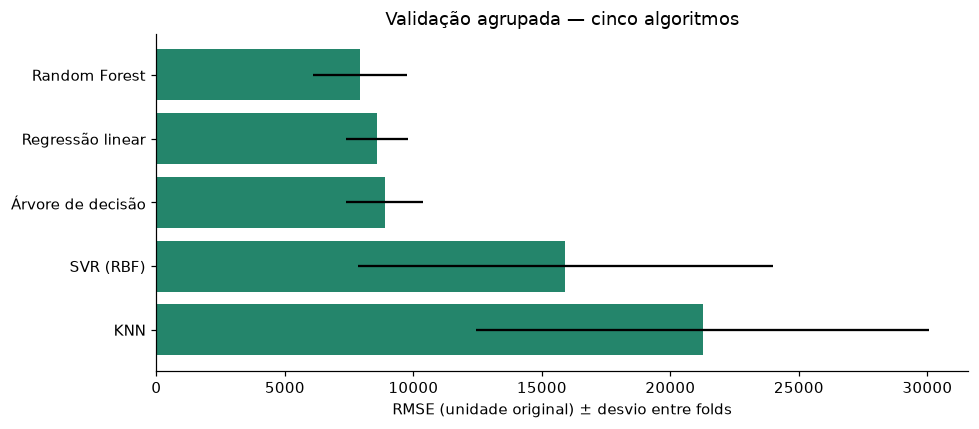

In [7]:
baselines = {
    'Média global': DummyRegressor(strategy='mean'),
    'Média por cultura': Pipeline([
        ('crop', ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['cultura'])])),
        ('model', LinearRegression(fit_intercept=False))
    ])
}
baseline_rows = []
for name, model in baselines.items():
    scores = cross_validate(model, X_train, y_train, cv=cv_splits, scoring=scoring, error_score='raise')
    baseline_rows.append({'modelo':name, 'MAE_CV':-scores['test_mae'].mean(),
                          'RMSE_CV':-scores['test_rmse'].mean(), 'R2_CV':scores['test_r2'].mean()})
    model.fit(X_train, y_train)
baseline_table = pd.DataFrame(baseline_rows)
display(baseline_table.round(3))
baseline_table.to_csv(OUT / 'referencias_validacao.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparison['modelo'], comparison['RMSE_CV'], xerr=comparison['RMSE_desvio_CV'], color='#24856b')
ax.invert_yaxis()
ax.set(xlabel='RMSE (unidade original) ± desvio entre folds', title='Validação agrupada — cinco algoritmos')
fig.tight_layout()
fig.savefig(OUT / 'modelos.png', bbox_inches='tight')
plt.show()

## 6. Avaliação final no teste reservado
Apenas o vencedor já escolhido e as duas referências são avaliados aqui. Os resultados
não retroalimentam a escolha de algoritmo, grid, features ou limpeza. Não excluímos
outliers para melhorar métricas. A comparação por cultura impede que um R² global
alto esconda desempenho fraco dentro de uma cultura.

,modelo,MAE,RMSE,R2
0,Random Forest,3300.746,4730.491,0.995
1,Média global,59215.183,69396.447,-0.000
2,Média por cultura,4077.381,5427.703,0.994


,cultura,n,MAE,RMSE,R2,RMSE_referencia_cultura
0,"Cocoa, beans",8,1587.016,1774.893,-0.102,1972.421
1,Oil palm fruit,8,7789.430,8507.735,0.134,9209.802
2,"Rice, paddy",8,2477.440,3385.778,0.539,5060.070
3,"Rubber, natural",8,1349.099,1585.845,0.286,1877.394


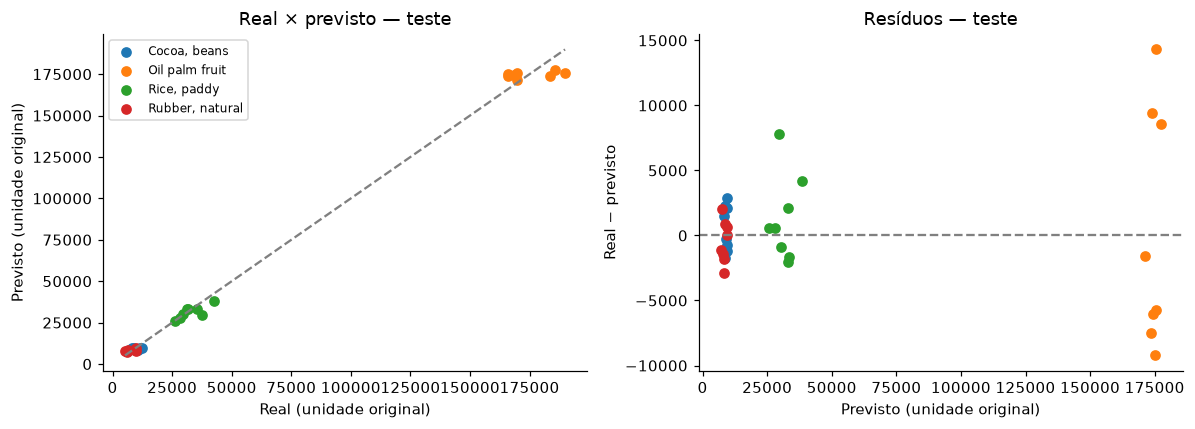

In [8]:
def metrics(actual, predicted):
    return {'MAE':float(mean_absolute_error(actual, predicted)),
            'RMSE':float(root_mean_squared_error(actual, predicted)),
            'R2':float(r2_score(actual, predicted))}
pred = best.predict(X_test)
crop_pred = baselines['Média por cultura'].predict(X_test)
final = pd.DataFrame([
    {'modelo':winner, **metrics(y_test, pred)},
    *[{'modelo':name, **metrics(y_test, model.predict(X_test))} for name, model in baselines.items()]
])
display(final.round(3))
final.to_csv(OUT / 'avaliacao_teste.csv', index=False)
results = X_test.copy()
results['real'] = y_test
results['previsto'] = pred
results['referencia_cultura'] = crop_pred
results['residuo'] = y_test - pred
results.to_csv(OUT / 'previsoes_teste.csv', index_label='indice_original')
per_crop = []
for crop, g in results.groupby('cultura'):
    per_crop.append({'cultura':crop, 'n':len(g), **metrics(g.real, g.previsto),
                     'RMSE_referencia_cultura':root_mean_squared_error(g.real, g.referencia_cultura)})
per_crop = pd.DataFrame(per_crop)
display(per_crop.round(3))
per_crop.to_csv(OUT / 'metricas_por_cultura.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for crop, g in results.groupby('cultura'):
    axes[0].scatter(g.real, g.previsto, label=crop)
    axes[1].scatter(g.previsto, g.residuo, label=crop)
limits = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(limits, limits, '--', color='gray')
axes[0].set(xlabel='Real (unidade original)', ylabel='Previsto (unidade original)', title='Real × previsto — teste')
axes[0].legend(fontsize=8)
axes[1].axhline(0, ls='--', color='gray')
axes[1].set(xlabel='Previsto (unidade original)', ylabel='Real − previsto', title='Resíduos — teste')
fig.tight_layout()
fig.savefig(OUT / 'teste.png', bbox_inches='tight')
plt.show()

In [9]:
w = final.iloc[0]
b = final.loc[final.modelo == 'Média por cultura'].iloc[0]
improvement = 100 * (b.RMSE - w.RMSE) / b.RMSE
assessment = 'reduziu' if improvement > 0 else 'aumentou'
display(Markdown(f'**Leitura do teste:** {winner} obteve MAE **{w.MAE:,.2f}**, RMSE **{w.RMSE:,.2f}** '
                 f'e R² global **{w.R2:.4f}**. O RMSE {assessment} **{abs(improvement):.1f}%** '
                 'em relação à referência por cultura. As métricas por cultura acima são essenciais: '
                 'a grande diferença entre as escalas de rendimento pode explicar boa parte do R² global. '
                 'Mesmo um ganho no teste não prova causalidade do clima nem generalização para outra fazenda.'))

**Leitura do teste:** Random Forest obteve MAE **3,300.75**, RMSE **4,730.49** e R² global **0.9954**. O RMSE reduziu **12.8%** em relação à referência por cultura. As métricas por cultura acima são essenciais: a grande diferença entre as escalas de rendimento pode explicar boa parte do R² global. Mesmo um ganho no teste não prova causalidade do clima nem generalização para outra fazenda.

## 7. Clusterização: regimes climáticos e produtividade
A análise não supervisionada abaixo é **descritiva da base completa**, feita após
congelar a avaliação preditiva. Seus rótulos e transformações não entram na regressão.

Aplicamos K-Means às quatro variáveis climáticas padronizadas dos 39 cenários únicos,
sem cultura nem rendimento. Isso evita obter apenas os quatro tipos de cultura
ou construir a separação diretamente pelo alvo. Comparamos k de 2 a 6 pela silhueta,
inspecionamos a inércia e verificamos estabilidade entre sementes com ARI.
A projeção PCA serve apenas para visualização: o ajuste usa as quatro dimensões.

Para comparar produtividade entre culturas, calculamos também um índice descritivo
`rendimento / mediana da própria cultura`. Valor 1 é a mediana, 1,1 representa 10%
acima dela. O índice usa toda a base e não é feature de previsão.

,k,silhueta,inercia
0,2,0.368,95.013
1,3,0.399,56.798
2,4,0.382,46.121
3,5,0.376,34.850
4,6,0.369,29.096


,precipitacao,umidade_especifica,umidade_relativa,temperatura
cluster,,,,
0,2733.518,18.338,85.652,26.119
1,2359.025,18.393,84.145,26.481
2,2232.217,17.805,83.916,25.986


,registros,indice_mediano,indice_medio,cenarios_unicos
cluster,,,,
0,68,1.022,1.020,17
1,44,0.993,1.007,11
2,44,0.981,0.996,11


n  rendimento_mediano  indice_mediano
cluster cultura                                                
0       Cocoa, beans     17              8300.0           0.938
        Oil palm fruit   17            175629.0           1.000
        Rice, paddy      17             33260.0           1.069
        Rubber, natural  17              7435.0           0.951
1       Cocoa, beans     11              8226.0           0.930
        Oil palm fruit   11            181496.0           1.033
        Rice, paddy      11             36361.0           1.169
        Rubber, natural  11              6275.0           0.803
2       Cocoa, beans     11              9003.0           1.018
        Oil palm fruit   11            169783.0           0.967
        Rice, paddy      11             26648.0           0.857
        Rubber, natural  11              9322.0           1.193

ARI entre sementes: mínimo 1.0 | média 1.0


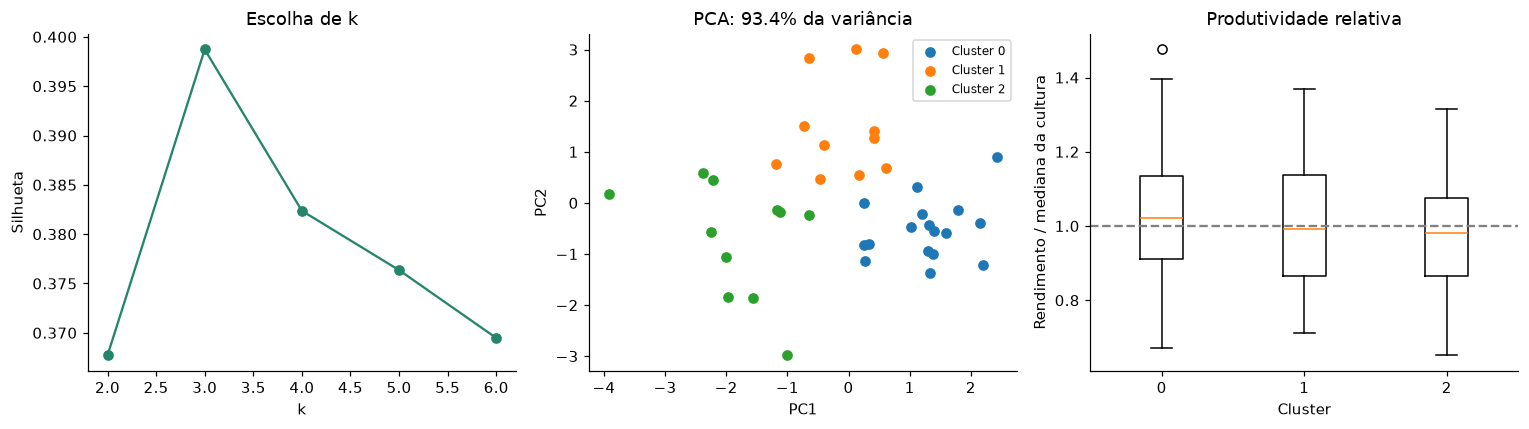

In [10]:
climate = df[NUM].drop_duplicates().reset_index(drop=True)
z = StandardScaler().fit_transform(climate)
k_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=30).fit(z)
    k_rows.append({'k':k, 'silhueta':silhouette_score(z, km.labels_), 'inercia':km.inertia_})
k_table = pd.DataFrame(k_rows)
k_best = int(k_table.loc[k_table.silhueta.idxmax(), 'k'])
km = KMeans(n_clusters=k_best, random_state=SEED, n_init=30).fit(z)
climate['cluster'] = km.labels_
ari = [adjusted_rand_score(km.labels_, KMeans(n_clusters=k_best, random_state=s, n_init=30).fit_predict(z)) for s in range(5)]
exploration = df.merge(climate, on=NUM, how='left', validate='many_to_one')
exploration['indice_produtividade'] = exploration.rendimento / exploration.groupby('cultura').rendimento.transform('median')
profiles = exploration.groupby('cluster').agg(registros=('rendimento','size'),
              indice_mediano=('indice_produtividade','median'), indice_medio=('indice_produtividade','mean'))
profiles['cenarios_unicos'] = climate.groupby('cluster').size()
display(k_table.round(3))
display(climate.groupby('cluster')[NUM].mean().round(3))
display(profiles.round(3))
display(exploration.groupby(['cluster','cultura']).agg(n=('rendimento','size'),
              rendimento_mediano=('rendimento','median'), indice_mediano=('indice_produtividade','median')).round(3))
print('ARI entre sementes: mínimo', round(min(ari),3), '| média', round(np.mean(ari),3))
profiles.to_csv(OUT / 'perfis_clusters.csv')
projection = PCA(n_components=2).fit(z)
xy = projection.transform(z)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(k_table.k, k_table.silhueta, 'o-', color='#24856b')
axes[0].set(xlabel='k', ylabel='Silhueta', title='Escolha de k')
for cluster in sorted(climate.cluster.unique()):
    mask = climate.cluster == cluster
    axes[1].scatter(xy[mask,0], xy[mask,1], label=f'Cluster {cluster}')
axes[1].legend(fontsize=8)
axes[1].set(xlabel='PC1', ylabel='PC2', title=f'PCA: {projection.explained_variance_ratio_.sum():.1%} da variância')
axes[2].boxplot([exploration.loc[exploration.cluster == c, 'indice_produtividade'] for c in sorted(climate.cluster.unique())], tick_labels=sorted(climate.cluster.unique()))
axes[2].axhline(1, ls='--', color='gray')
axes[2].set(xlabel='Cluster', ylabel='Rendimento / mediana da cultura', title='Produtividade relativa')
fig.tight_layout()
fig.savefig(OUT / 'clusters.png', bbox_inches='tight')
plt.show()

In [11]:
strong = profiles.indice_mediano.idxmax()
weak = profiles.indice_mediano.idxmin()
display(Markdown(f'**Tendência descritiva:** a maior silhueta selecionou **k={k_best}**. '
                 f'O cluster {strong} apresenta o maior índice mediano ({profiles.loc[strong,"indice_mediano"]:.3f}) '
                 f'e o cluster {weak}, o menor ({profiles.loc[weak,"indice_mediano"]:.3f}). '
                 'A tabela por cultura mostra se essa associação é consistente entre plantações. '
                 'Os clusters são regimes climáticos observados; seus números não representam ordem ou qualidade. '
                 'Silhueta e estabilidade avaliam a partição geométrica, sem validar uma explicação agronômica.'))

**Tendência descritiva:** a maior silhueta selecionou **k=3**. O cluster 0 apresenta o maior índice mediano (1.022) e o cluster 2, o menor (0.981). A tabela por cultura mostra se essa associação é consistente entre plantações. Os clusters são regimes climáticos observados; seus números não representam ordem ou qualidade. Silhueta e estabilidade avaliam a partição geométrica, sem validar uma explicação agronômica.

## 8. Cenários discrepantes
Combinamos dois critérios independentes e mantemos todos os registros:
- **IQR dentro de cada cultura:** rendimento abaixo de Q1 − 1,5×IQR ou acima de Q3 + 1,5×IQR.
- **Isolation Forest nos cenários climáticos:** ranqueia combinações multivariadas
  atípicas, com `contamination='auto'`. Esse limiar é heurístico; não é uma taxa de
  anomalias conhecida nem uma prova de erro. Mostramos os cinco cenários mais atípicos,
  além da sinalização automática.

Uma observação incomum pode ser válida. Removê-la exigiria conferir fonte, sensor,
unidade ou condições de manejo. As quatro linhas de um cenário climático discrepante
não são quatro eventos independentes.

In [12]:
quartiles = exploration.groupby('cultura').rendimento.quantile([0.25,0.75]).unstack()
q1 = exploration.cultura.map(quartiles[0.25])
q3 = exploration.cultura.map(quartiles[0.75])
iqr = q3 - q1
exploration['outlier_rendimento_iqr'] = (exploration.rendimento < q1 - 1.5*iqr) | (exploration.rendimento > q3 + 1.5*iqr)
iso = IsolationForest(n_estimators=300, random_state=SEED, contamination='auto', n_jobs=1).fit(z)
climate['score_anomalia'] = -iso.score_samples(z)
climate['outlier_climatico'] = iso.predict(z) == -1
exploration = exploration.merge(climate[[*NUM,'score_anomalia','outlier_climatico']], on=NUM, validate='many_to_one')
display(climate.sort_values('score_anomalia', ascending=False).head(5))
display(exploration.loc[exploration.outlier_rendimento_iqr, ['cultura','rendimento','indice_produtividade',*NUM]])
exploration.to_csv(OUT / 'clusters_outliers.csv', index=False)
n_iqr = int(exploration.outlier_rendimento_iqr.sum())
n_iso = int(climate.outlier_climatico.sum())
display(Markdown(f'**Resultado:** o IQR identificou **{n_iqr} registros** com rendimento discrepante dentro da cultura; '
                 f'Isolation Forest sinalizou **{n_iso} de {len(climate)} cenários climáticos** pelo limiar automático. '
                 'A sinalização é exploratória; nenhum registro foi excluído do treino ou do teste por esses critérios.'))

,precipitacao,umidade_especifica,umidade_relativa,temperatura,cluster,score_anomalia,outlier_climatico
1,1938.42,17.54,82.11,26.11,2,0.655507,True
3,2592.35,17.61,85.07,25.56,2,0.605662,True
36,2967.41,18.67,85.48,26.46,0,0.573174,True
17,2362.80,18.70,84.03,26.79,1,0.567540,True
38,2109.34,18.51,83.52,26.72,1,0.564601,True


,cultura,rendimento,indice_produtividade,precipitacao,umidade_especifica,umidade_relativa,temperatura


**Resultado:** o IQR identificou **0 registros** com rendimento discrepante dentro da cultura; Isolation Forest sinalizou **13 de 39 cenários climáticos** pelo limiar automático. A sinalização é exploratória; nenhum registro foi excluído do treino ou do teste por esses critérios.

## 9. Demonstração de inferência e conclusão
A demonstração usa uma linha do teste para mostrar o contrato de entrada; não
representa nova validação nem medição real de sensor. O modelo recebe cultura e quatro
números e retorna rendimento na escala original do CSV.

In [13]:
example = X_test.iloc[[0]].copy()
display(example)
print('Rendimento previsto (unidade original):', round(float(best.predict(example)[0]), 2))
summary = {'dataset_sha256':sha256, 'registros':len(df), 'cenarios_climaticos':int(groups.nunique()),
           'linhas_treino':len(train_idx), 'linhas_teste':len(test_idx), 'modelo_selecionado':winner,
           'metricas_teste':metrics(y_test,pred), 'rmse_referencia_cultura':float(b.RMSE),
           'melhoria_rmse_percentual':float(improvement), 'k':k_best,
           'silhueta':float(k_table.loc[k_table.k == k_best,'silhueta'].iloc[0]),
           'outliers_iqr':n_iqr, 'cenarios_outliers_isolation_forest':n_iso, 'versoes':VERSIONS}
(OUT / 'resumo.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura
0,"Cocoa, beans",2248.92,17.72,83.4,26.01


Rendimento previsto (unidade original): 9439.99


671

### Síntese dos resultados desta execução

A Random Forest foi selecionada pelo menor RMSE médio de validação (7.916,82).
No teste de oito cenários (32 linhas), obteve RMSE de **4.730,49**, MAE de **3.300,75**
e R² global de **0,9954**. O RMSE da média por cultura foi 5.427,70: o modelo reduziu
esse erro em **12,85%**. Todas as medidas de erro estão na unidade original do CSV.

O R² por cultura mostra o limite do resultado global: **cacau −0,102; dendê 0,134;
arroz 0,539; borracha 0,286**. O valor negativo do cacau significa que, nesse teste,
o modelo foi pior que prever a média dos valores reais desse subconjunto, embora
seu RMSE ainda seja menor que o da referência por cultura aprendida no treino.
Não se deve traduzir R² em percentual de acerto nem tratar esse modelo como pronto
para orientar decisões agronômicas.

O K-Means selecionou **três clusters**, com silhueta **0,399**. Os índices medianos de
produtividade foram **1,022**, **0,993** e **0,981**, respectivamente nos clusters 0, 1 e 2.
As distribuições se sobrepõem bastante: a associação entre regime climático e
produtividade é discreta e descritiva, sem evidência causal. A análise IQR não sinalizou
rendimentos discrepantes dentro das culturas. O Isolation Forest marcou **13 de 39
cenários** pelo limiar automático; essa proporção elevada reforça a necessidade de
inspeção humana e não justifica excluir um terço dos cenários.

### Pontos fortes
A execução é reprodutível e preserva a base. A avaliação impede que condições climáticas
idênticas atravessem treino e teste, inclui referências global e por cultura e apresenta
erros por cultura. Cinco algoritmos são comparados sob as mesmas partições. A análise
não supervisionada separa agrupamento climático e leitura da produtividade.

### Limitações e próximos passos
São somente 39 cenários e oito deles ficam no teste. O ajuste dos grids reutiliza as
partições de validação, portanto o ranking de CV deve ser interpretado com cautela.
A coincidência de variáveis não identifica necessariamente os grupos reais de coleta;
metadados de tempo e local permitiriam validação mais adequada. Um R² global elevado
pode ser consequência das diferenças entre culturas, sem bom desempenho dentro delas.

A ausência de solo, manejo, variedade, data e local limita a explicação dos rendimentos.
As unidades precisam ser confirmadas com a FIAP antes de divulgar previsões em t/ha.
Clusters e outliers são hipóteses de investigação, não diagnósticos agronômicos.
Antes de hospedar uma API, será necessário validar com novas safras, estabelecer o
contrato de unidades, tratar culturas desconhecidas e medir memória e latência.
Esta entrega faz a estimativa de nuvem; não demonstra uma implantação em produção.

### Referências
- [Validação cruzada e grupos — scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Boas práticas e vazamento de dados — scikit-learn](https://scikit-learn.org/stable/common_pitfalls.html)
- [Clusterização — scikit-learn](https://scikit-learn.org/stable/modules/clustering.html)
- [Detecção de outliers — scikit-learn](https://scikit-learn.org/stable/modules/outlier_detection.html)
- Enunciado da FIAP: Projeto Fase 5 — Machine Learning na Cabeça, fornecido pelo integrante.